<table align="left" width=100%>
    <tr>
        <td width="20%">
            <img src="GL-2.png">
        </td>
        <td>
            <div align="center">
                <font color="#21618C" size=8px>
                  <b> Faculty Notebook <br> (Week 3) </b>
                </font>
            </div>
        </td>
    </tr>
</table>

## Table of Content
1. **[Concatenate](#Concatenate)**
2. **[Merging and Joining](#Merging)**
3. **[Pivot Table](#Pivote)**
4. **[Cross Table](#crosst)**
5. **[Duplicate](#Duplicate)**
6. **[Dropping Rows and Columns](#drop)**
7. **[Map and Replace](#Map)**
8. **[Groupby in Pandas](#Groupby)**
9. **[Plots using Matplotlib ](#matplotlib)**

<a id="Concatenate"> </a>
### 1. Concatenate

Concatenation is a process of joining objects along a particular axis, with set logic applied along the other axes, if any (a series does not have any other axes)<br>
                   The main parameters involved in pandas concatenation are - object, axis, handling of other axes, and keys.

**Concatenate pandas Series**

In [ ]:
# import the library pandas as pd
import pandas as pd

# import the library NumPy as np
import numpy as np

In [ ]:
# create a series from list
sales_a = pd.Series([101,102,103,104,105,106])

# create another series from list
sales_b = pd.Series([107,108,109,110,111,112])

In [ ]:
pd.concat([sales_a,sales_b],keys=["sales_a","sales_b"],axis=1)

,sales_a,sales_b
0,101,107
1,102,108
2,103,109
3,104,110
4,105,111
5,106,112


In [ ]:
# concatenate the pandas series
pd.concat([sales_a,sales_b])

,0
0,101
1,102
2,103
3,104
4,105
5,106
0,107
1,108
2,109
3,110


**Add a hierarchical index to a pandas Series**

In [ ]:
# concatenate the series
# keys adds hierarchical indexes
pd.concat([sales_a,sales_b], keys = ['sales_a', 'sales_b'])

sales_a  0    101
         1    102
         2    103
         3    104
         4    105
         5    106
sales_b  0    107
         1    108
         2    109
         3    110
         4    111
         5    112
dtype: int64

**Label the index**

In [ ]:
# 'names' parameter assigns labels to 'keys' and 'indexes'
pd.concat([sales_a, sales_b], keys=['a', 'b'], names=['Series', 'Row ID'])

Series  Row ID
a       0         101
        1         102
        2         103
        3         104
        4         105
        5         106
b       0         107
        1         108
        2         109
        3         110
        4         111
        5         112
dtype: int64

**Concatenating DataFrames**

To concatenate DataFrames, let us first create three DataFrame
1. df_prof_info_A: professional information on employees of company A
2. df_prof_info_B: professional information on employees of company B
3. df_pers_info_A: personal information on employees of company A


In [ ]:
# create a DataFrame from a dictionary
import pandas as pd
df_prof_info_A = pd.DataFrame({
   'Emp_ID': [1001,1002,1003,1004,1005],
   'Name': ['Alex', 'Amy', 'Allen', 'Alice', 'Stephan'],
   'Gender':['M', 'F', 'M', 'F', 'M'],
   'Company':['Apple','Walmart','Intel','Cummins','Ford'],
   'Salary':[67000,90000,87000,69000,78000]},
   index=[101,102,103,104,105])

# print the DataFrame
print("The first DataFrame is : \n",df_prof_info_A)

print("\n\n")

# create a DataFrame from a dictionary
df_prof_info_B = pd.DataFrame({
    'Emp_ID': [1006,1007,1008,1009,1010,1011],
   'Name': ['Billy', 'Brian', 'Bran', 'Bryce', 'Betty','James'],
    'Gender':['M', 'M', 'M', 'F', 'F','M'],
   'Company':['Cognizant','Apple','Intel','Cummins','Walmart','Intel'],
   'Salary':[89000,80000,79000,97000,88000,89000]},
   index=[106,107,108,109,110,111])

# print the DataFrame
print("The second DataFrame is : \n",df_prof_info_B)

print("\n\n")

# create a DataFrame from a dictionary
df_pers_info_A = pd.DataFrame({
     'Emp_ID': [1001,1002,1003,1004,1005],
   'Hometown': ['New York', 'London', 'San Francisco', 'Seattle', 'Madrid'],
     'Gender':['M', 'F', 'M', 'F', 'M'],
    'Marital':['Married','Divorsed','Single','Married','Single']  ,
   'Dependents':[1,1,3,2,1]},
   index=[101,102,103,104,105])

# print the DataFrame
print("The third DataFrame is : \n",df_pers_info_A)

print("\n\n")

# create a DataFrame from a dictionary
df_pers_info_B = pd.DataFrame({
     'Emp_ID': [1006,1007,1009,1010,1011,1012],
   'Hometown': ['Paris', 'Boston', 'San Francisco', 'Seattle', 'London','London'],
    'Marital':['Married','Divorsed','Single','Married','Single','Single'],
   'Dependents':[1,1,3,2,1,2]},
   index=[106,107,108,109,110,111])

# print the DataFrame
print("The fourth DataFrame is : \n",df_pers_info_B)

The first DataFrame is : 
      Emp_ID     Name Gender  Company  Salary
101    1001     Alex      M    Apple   67000
102    1002      Amy      F  Walmart   90000
103    1003    Allen      M    Intel   87000
104    1004    Alice      F  Cummins   69000
105    1005  Stephan      M     Ford   78000



The second DataFrame is : 
      Emp_ID   Name Gender    Company  Salary
106    1006  Billy      M  Cognizant   89000
107    1007  Brian      M      Apple   80000
108    1008   Bran      M      Intel   79000
109    1009  Bryce      F    Cummins   97000
110    1010  Betty      F    Walmart   88000
111    1011  James      M      Intel   89000



The third DataFrame is : 
      Emp_ID       Hometown Gender   Marital  Dependents
101    1001       New York      M   Married           1
102    1002         London      F  Divorsed           1
103    1003  San Francisco      M    Single           3
104    1004        Seattle      F   Married           2
105    1005         Madrid      M    Single    

**Concatenating pandas DataFrames using `.concat()`**

**Combine DataFrames vertically**

In [ ]:
pd.concat([df_prof_info_A,df_pers_info_A],axis=1).T.drop_duplicates().T

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
101,1001,Alex,M,Apple,67000,New York,Married,1
102,1002,Amy,F,Walmart,90000,London,Divorsed,1
103,1003,Allen,M,Intel,87000,San Francisco,Single,3
104,1004,Alice,F,Cummins,69000,Seattle,Married,2
105,1005,Stephan,M,Ford,78000,Madrid,Single,1


In [ ]:
pd.concat([df_prof_info_A,df_prof_info_B])

,Emp_ID,Name,Gender,Company,Salary
101,1001,Alex,M,Apple,67000
102,1002,Amy,F,Walmart,90000
103,1003,Allen,M,Intel,87000
104,1004,Alice,F,Cummins,69000
105,1005,Stephan,M,Ford,78000
106,1006,Billy,M,Cognizant,89000
107,1007,Brian,M,Apple,80000
108,1008,Bran,M,Intel,79000
109,1009,Bryce,F,Cummins,97000
110,1010,Betty,F,Walmart,88000


In [ ]:
pd.concat([df_prof_info_A,df_prof_info_B],axis=0)

,Emp_ID,Name,Gender,Company,Salary
101,1001,Alex,M,Apple,67000
102,1002,Amy,F,Walmart,90000
103,1003,Allen,M,Intel,87000
104,1004,Alice,F,Cummins,69000
105,1005,Stephan,M,Ford,78000
106,1006,Billy,M,Cognizant,89000
107,1007,Brian,M,Apple,80000
108,1008,Bran,M,Intel,79000
109,1009,Bryce,F,Cummins,97000
110,1010,Betty,F,Walmart,88000


In [ ]:
pd.concat([df_prof_info_A,df_pers_info_A],axis=1).drop_duplicates()

,Emp_ID,Name,Gender,Company,Salary,Emp_ID,Hometown,Gender,Marital,Dependents
101,1001,Alex,M,Apple,67000,1001,New York,M,Married,1
102,1002,Amy,F,Walmart,90000,1002,London,F,Divorsed,1
103,1003,Allen,M,Intel,87000,1003,San Francisco,M,Single,3
104,1004,Alice,F,Cummins,69000,1004,Seattle,F,Married,2
105,1005,Stephan,M,Ford,78000,1005,Madrid,M,Single,1


In [ ]:
pd.concat([df_prof_info_A,df_pers_info_A],axis=1).T.drop_duplicates().T

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
101,1001,Alex,M,Apple,67000,New York,Married,1
102,1002,Amy,F,Walmart,90000,London,Divorsed,1
103,1003,Allen,M,Intel,87000,San Francisco,Single,3
104,1004,Alice,F,Cummins,69000,Seattle,Married,2
105,1005,Stephan,M,Ford,78000,Madrid,Single,1


In [ ]:
# concatenate the data frame
print(pd.concat([df_prof_info_A,df_prof_info_B]))

     Emp_ID     Name Gender    Company  Salary
101    1001     Alex      M      Apple   67000
102    1002      Amy      F    Walmart   90000
103    1003    Allen      M      Intel   87000
104    1004    Alice      F    Cummins   69000
105    1005  Stephan      M       Ford   78000
106    1006    Billy      M  Cognizant   89000
107    1007    Brian      M      Apple   80000
108    1008     Bran      M      Intel   79000
109    1009    Bryce      F    Cummins   97000
110    1010    Betty      F    Walmart   88000
111    1011    James      M      Intel   89000


**Combine DataFrames horizontally**

In [ ]:
# combine Pandas Dataframes horizontally
# axis specifies the axis to concatenate along, here 1 indicates columns
pd.concat([df_prof_info_A, df_pers_info_A], axis=1)

,Emp_ID,Name,Gender,Company,Salary,Emp_ID,Hometown,Gender,Marital,Dependents
101,1001,Alex,M,Apple,67000,1001,New York,M,Married,1
102,1002,Amy,F,Walmart,90000,1002,London,F,Divorsed,1
103,1003,Allen,M,Intel,87000,1003,San Francisco,M,Single,3
104,1004,Alice,F,Cummins,69000,1004,Seattle,F,Married,2
105,1005,Stephan,M,Ford,78000,1005,Madrid,M,Single,1


Combining DataFrames horizontally with duplicate columns removed.

In [ ]:
# combine DataFrame with duplicate columns removed
# T: transposes the DataFrame
# drop_duplicates(): drops the duplicate rows in a DataFrame
pd.concat([df_prof_info_A, df_pers_info_A], axis=1).T.drop_duplicates().T

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
101,1001,Alex,M,Apple,67000,New York,Married,1
102,1002,Amy,F,Walmart,90000,London,Divorsed,1
103,1003,Allen,M,Intel,87000,San Francisco,Single,3
104,1004,Alice,F,Cummins,69000,Seattle,Married,2
105,1005,Stephan,M,Ford,78000,Madrid,Single,1


**Concatenating data frames ignoring index values**

In [ ]:
# concatenate DataFrames
# ignore_index if True, assigns index values begining with zero
pd.concat([df_prof_info_A, df_prof_info_B], ignore_index=True)

,Emp_ID,Name,Gender,Company,Salary
0,1001,Alex,M,Apple,67000
1,1002,Amy,F,Walmart,90000
2,1003,Allen,M,Intel,87000
3,1004,Alice,F,Cummins,69000
4,1005,Stephan,M,Ford,78000
5,1006,Billy,M,Cognizant,89000
6,1007,Brian,M,Apple,80000
7,1008,Bran,M,Intel,79000
8,1009,Bryce,F,Cummins,97000
9,1010,Betty,F,Walmart,88000


In [ ]:
## MERGE--> COMBINE TWO TABLE TO FROM SINGLE TABLE,
## MERGE THE TABLE ON THE BASIS OF COMMON COLUMN
pd.merge(df_prof_info_A, df_pers_info_A,on="Emp_ID")

,Emp_ID,Name,Gender_x,Company,Salary,Hometown,Gender_y,Marital,Dependents
0,1001,Alex,M,Apple,67000,New York,M,Married,1
1,1002,Amy,F,Walmart,90000,London,F,Divorsed,1
2,1003,Allen,M,Intel,87000,San Francisco,M,Single,3
3,1004,Alice,F,Cummins,69000,Seattle,F,Married,2
4,1005,Stephan,M,Ford,78000,Madrid,M,Single,1


**Concatenating Pandas Dataframes using `.append()`**

In [ ]:
df_prof_info_A._append(df_prof_info_B)

,Emp_ID,Name,Gender,Company,Salary
101,1001,Alex,M,Apple,67000
102,1002,Amy,F,Walmart,90000
103,1003,Allen,M,Intel,87000
104,1004,Alice,F,Cummins,69000
105,1005,Stephan,M,Ford,78000
106,1006,Billy,M,Cognizant,89000
107,1007,Brian,M,Apple,80000
108,1008,Bran,M,Intel,79000
109,1009,Bryce,F,Cummins,97000
110,1010,Betty,F,Walmart,88000


In [ ]:
# append DataFrame df_company_B to df_company_A
df_prof_info_A._append(df_prof_info_B)

,Emp_ID,Name,Gender,Company,Salary
101,1001,Alex,M,Apple,67000
102,1002,Amy,F,Walmart,90000
103,1003,Allen,M,Intel,87000
104,1004,Alice,F,Cummins,69000
105,1005,Stephan,M,Ford,78000
106,1006,Billy,M,Cognizant,89000
107,1007,Brian,M,Apple,80000
108,1008,Bran,M,Intel,79000
109,1009,Bryce,F,Cummins,97000
110,1010,Betty,F,Walmart,88000


<a id="Merging"> </a>
### 2. Merging and Joining

Merging two datasets is a process of bringing two datasets to form one, by aligning the rows from both the datasets based on common attributes or columns

### Concatenate using `.merge()`

Concatenate the personal and professional information on employees in company A.

In [ ]:
# concatenate the DataFrames
# 'on' specifies the column(s) based on which to join the DataFrames
# suffixes: specifies the suffix for duplicate columns
# the (' ',' ') indicates there are no suffixes given
# T: transposes the DataFrame
# drop_duplicates(): drops the duplicate rows in a DataFrame
pd.merge(df_prof_info_A, df_pers_info_A)

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
0,1001,Alex,M,Apple,67000,New York,Married,1
1,1002,Amy,F,Walmart,90000,London,Divorsed,1
2,1003,Allen,M,Intel,87000,San Francisco,Single,3
3,1004,Alice,F,Cummins,69000,Seattle,Married,2
4,1005,Stephan,M,Ford,78000,Madrid,Single,1


The rows having common employee ID's are merged to give the resultant DataFrame.

**Merging using multiple keys**

Now, let us Concatenate the personal and professional information on employees in company A.

In [ ]:
# concatenate the DataFrames
# 'on' specifies the column(s) based on which to join the DataFrames
pd.merge(df_prof_info_A, df_pers_info_A)

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
0,1001,Alex,M,Apple,67000,New York,Married,1
1,1002,Amy,F,Walmart,90000,London,Divorsed,1
2,1003,Allen,M,Intel,87000,San Francisco,Single,3
3,1004,Alice,F,Cummins,69000,Seattle,Married,2
4,1005,Stephan,M,Ford,78000,Madrid,Single,1


The rows having common employee ID and gender are merged to give the resultant DataFrame.

**Merging on the Basis of Index**

This function helps to merge two DataFrames, based on their index.

In [ ]:
# merge the DataFrames based on their index
# 'left_index' considers index of left DataFrame to merge, here it is set to True, so it is considered
# 'right_index' considers index of right DataFrame to merge, here it is set to False, so it is not considered
# 'on' specifies the column(s) based on which to join the DataFrames
# suffixes: specifies the suffix for duplicate columns
# the (' ',' ') indicates there are no suffixes given
# T: transposes the DataFrame
# drop_duplicates(): drops the duplicate rows in a DataFrame
pd.merge(df_prof_info_A, df_pers_info_A,  right_index = False, left_index = True, on='Emp_ID', suffixes =(' ',' ')
        ).T.drop_duplicates().T

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
101,1001,Alex,M,Apple,67000,New York,Married,1
102,1002,Amy,F,Walmart,90000,London,Divorsed,1
103,1003,Allen,M,Intel,87000,San Francisco,Single,3
104,1004,Alice,F,Cummins,69000,Seattle,Married,2
105,1005,Stephan,M,Ford,78000,Madrid,Single,1


Note the resultant DataFrame takes the index of the DataFrame to the left.

**`merge()` allows you to perform natural join, left join, right join, and full outer join in pandas.**

**Understanding the Different Types of Merge:**

Left outer join: includes all the rows of your DataFrame x and only those from y that match. (how=‘left’).

Right outer join: includes all the rows of your DataFrame y and only those from x that match. (how=‘right’).

Inner join: includes those rows that are common to both the DataFrames. (how=‘inner’).

Full outer join: includes all rows from both DataFrames. (how=‘outer’).

**Inner Join:**<br>
It returns only the rows in which the left table has matching keys in the right table.

In [ ]:
# print the inner join of the DataFrames
# on specifies the column(s) based on which to join the DataFrames
# how specifies the type of join
pd.merge(df_prof_info_B, df_pers_info_B, on='Emp_ID', how='inner')

KeyError: 'Gender'

In professional info B we have employee ID's as 1006,1007,1008,1009,1010,1011 and we have personal info B for employee ID's 1006,1007,1009,1010,1011,1012. Because of the inner join, we notice that 1008 from the first DataFrame (professinal info) and 1012 from second DataFrame (personal info) are not part to the resultant outcome. In other words, inner join will include those rows that are common to both the DataFrames.

**Outer Join:**<br>
It returns all rows from both tables, joining records from the left, which has matching keys in the right table.

In [ ]:
# print the outer join of the DataFrames
# on specifies the column(s) based on which to join the DataFrames
# how specifies the type of join
pd.merge(df_prof_info_B, df_pers_info_B, on='Emp_ID', how='outer')

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
0,1006,Billy,M,Cognizant,89000.0,Paris,Married,1.0
1,1007,Brian,M,Apple,80000.0,Boston,Divorsed,1.0
2,1008,Bran,M,Intel,79000.0,NaN,NaN,NaN
3,1009,Bryce,F,Cummins,97000.0,San Francisco,Single,3.0
4,1010,Betty,F,Walmart,88000.0,Seattle,Married,2.0
5,1011,James,M,Intel,89000.0,London,Single,1.0
6,1012,NaN,NaN,NaN,NaN,London,Single,2.0


In professional info B we have employee ID's as 1006,1007,1008,1009,1010,1011 and we have personal info B for employee ID's 1006,1007,1009,1010,1011,1012. <br>The employee Id 1008 has no personal information available and the employee ID 1012 has no professional information available. <br>So, the outer join merged all the observations from both the DataFrames and all the missing values are marked with `NaN`.

**Left Outer Join:**<br>
It returns all rows from the left table and any rows with matching keys from the right table.

In [ ]:
# print the left join of the DataFrames
# on specifies the column(s) based on which to join the DataFrames
# how specifies the type of join
pd.merge(df_prof_info_B, df_pers_info_B, on = 'Emp_ID', how ='left')

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
0,1006,Billy,M,Cognizant,89000,Paris,Married,1.0
1,1007,Brian,M,Apple,80000,Boston,Divorsed,1.0
2,1008,Bran,M,Intel,79000,NaN,NaN,NaN
3,1009,Bryce,F,Cummins,97000,San Francisco,Single,3.0
4,1010,Betty,F,Walmart,88000,Seattle,Married,2.0
5,1011,James,M,Intel,89000,London,Single,1.0


We notice that employee ID 1008 is present in left DataFrame but not present in the right DataFrame.

Whereas employee ID 1012 is present in right DataFrame but not present in the left DataFrame.

Because of `how = 'left'`, it took all the observations from the left DataFrame (professional info) but it took only those observations from the right DataFrame (personal info) which are present in the left DataFrame and all the missing values are marked with `NaN`.

**Right Outer Join:**<br>
It returns all rows from the right table and any rows with matching keys from the left table.

In [ ]:
# print the right join of the DataFrames
# on specifies the column(s) based on which to join the DataFrames
# how specifies the type of join
pd.merge(df_prof_info_B, df_pers_info_B, on='Emp_ID', how='right')

,Emp_ID,Name,Gender,Company,Salary,Hometown,Marital,Dependents
0,1006,Billy,M,Cognizant,89000.0,Paris,Married,1
1,1007,Brian,M,Apple,80000.0,Boston,Divorsed,1
2,1009,Bryce,F,Cummins,97000.0,San Francisco,Single,3
3,1010,Betty,F,Walmart,88000.0,Seattle,Married,2
4,1011,James,M,Intel,89000.0,London,Single,1
5,1012,NaN,NaN,NaN,NaN,London,Single,2


We notice that employee ID 1012 is present in right DataFrame but not present in the left DataFrame.

Whereas employee ID 1008 is present in left DataFrame but not present in the right DataFrame.

Because of `how = 'right'`, it took all the observations from the right DataFrame (personal info) but it took only those observations from the left DataFrame (professional info) which are present in the right DataFrame and all the missing values are marked with `NaN`.

<a id="Pivote"> </a>
### 3. Pivot Table


The pivot_table() is used to create a new table for the given index. Pivot has three arguments - index, columns, and values.

In [ ]:
# create a dictionary
sales = {'Months': ['Jan','Feb','Mar','Apr','May','June','July','Aug','Sep','Oct','Nov','Dec'],
        'Sales': [22000,27000,25000,29000,35000,67000,78000,67000,56000,56000,89000,60000],
         'Seasons': ['Winter','Winter','Spring','Spring','Spring','Summer','Summer','Summer','Fall','Fall','Fall','Winter']
        }

# create a DataFrame
df_sales = pd.DataFrame(sales, columns= ['Months', 'Sales','Seasons'])

# print the DataFrame
df_sales

,Months,Sales,Seasons
0,Jan,22000,Winter
1,Feb,27000,Winter
2,Mar,25000,Spring
3,Apr,29000,Spring
4,May,35000,Spring
5,June,67000,Summer
6,July,78000,Summer
7,Aug,67000,Summer
8,Sep,56000,Fall
9,Oct,56000,Fall


The simplest pivot table must have a dataframe and an index . In this case, let us use the 'Months' as our index.

In [ ]:
# create a pivot table where indexes are months
pd.pivot_table(df_sales,index=["Seasons"],columns="Months",values="Sales",aggfunc="sum",fill_value=" ")

Months,Apr,Aug,Dec,Feb,Jan,July,June,Mar,May,Nov,Oct,Sep
Seasons,,,,,,,,,,,,
Fall,,,,,,,,,,89000,56000,56000
Spring,29000,,,,,,,25000,35000,,,
Summer,,67000,,,,78000,67000,,,,,
Winter,,,60000,27000,22000,,,,,,,


It is possible to create pivot tables over multiple indexes.

In [ ]:
# to create pivot table having multiple indexes
# index is a list of column names to be considered as indexes
pd.pivot_table(df_sales,index=["Months", "Seasons"])

,,Sales
Months,Seasons,
Apr,Spring,29000
Aug,Summer,67000
Dec,Winter,60000
Feb,Winter,27000
Jan,Winter,22000
July,Summer,78000
June,Summer,67000
Mar,Spring,25000
May,Spring,35000


To create a pivot table for with the index as 'Seasons'. Also, set the values to be 'Sales'.

In [ ]:
# create a pivot table for with the index as 'Seasons' and values as 'Sales'
# index is a list of column names to be considered as indexes
# values represent the numeric data
pd.pivot_table(df_sales,index=["Seasons"],values=["Sales"])

,Sales
Seasons,
Fall,67000.000000
Spring,29666.666667
Summer,70666.666667
Winter,36333.333333


The output gives the average sale in each season. The argument `aggfunc` by default will find the average of all values for an index. For example, for the index `Fall`, the average of all the observation having index 'Fall' is given

However, if one is not interested in the average, it is also possible to find the count or the sum of the observations.

Let us find the sum of sales in each season.

In [ ]:
# to create a pivot table for with the index as 'Seasons' and values as 'Sales'
# index is a list of column names to be considered as indexes
# values represent the numeric data
# aggfunc specifies the function
pd.pivot_table(df_sales,index=["Seasons"],values=["Sales"], aggfunc=np.sum)

,Sales
Seasons,
Fall,201000
Spring,89000
Summer,212000
Winter,109000


The `aggfunc` can take a list of functions.

In [ ]:
# to create a pivot table for with the index as 'Seasons' and values as 'Sales'
# index is a list of column names to be considered as indexes
# values represent the numeric data
# aggfunc specifies the function
# find the average and count of observations for each season
pd.pivot_table(df_sales,index=["Seasons"],values=["Sales"], aggfunc=[np.mean,len])

,mean,len
,Sales,Sales
Seasons,,
Fall,67000.000000,3
Spring,29666.666667,3
Summer,70666.666667,3
Winter,36333.333333,3


The output gives the function used above the column name. We see that the mean and count of observations are given.

It is possible to create two-dimensional pivot_tables.

In [ ]:
# create a pivot table for with the index as 'Months', values as 'Sales' and columns as 'Seasons'
# index is a list of column names to be considered as indexes
# values represent the numeric data
# columns is categorical variable(s) whose categories form the columns of the pivot table
# aggfunc specifies the function
# find the sum observations for each season and month
pd.pivot_table(df_sales, index = ["Months"], values = ["Sales"], columns = ["Seasons"], aggfunc = [np.sum])

sum                           
           Sales                           
Seasons     Fall   Spring   Summer   Winter
Months                                     
Apr          NaN  29000.0      NaN      NaN
Aug          NaN      NaN  67000.0      NaN
Dec          NaN      NaN      NaN  60000.0
Feb          NaN      NaN      NaN  27000.0
Jan          NaN      NaN      NaN  22000.0
July         NaN      NaN  78000.0      NaN
June         NaN      NaN  67000.0      NaN
Mar          NaN  25000.0      NaN      NaN
May          NaN  35000.0      NaN      NaN
Nov      89000.0      NaN      NaN      NaN
Oct      56000.0      NaN      NaN      NaN
Sep      56000.0      NaN      NaN      NaN

The above table is a bit gaudy to look. Let us replace the NaN's with 0's.

In [ ]:
# create a pivot table for with the index as 'Months', values as 'Sales' and columns as 'Seasons'
# index is a list of column names to be considered as indexes
# values represent the numeric data
# columns is categorical variable(s) whose categories form the columns of the pivot table
# aggfunc specifies the function
# find the sum observations for each season and month
# use fill_value to replace all NaN's as 0's
pd.pivot_table(df_sales, index = ["Months"], values = ["Sales"], columns = ["Seasons"],
               aggfunc = [np.sum], fill_value = 0)

sum                     
         Sales                     
Seasons   Fall Spring Summer Winter
Months                             
Apr          0  29000      0      0
Aug          0      0  67000      0
Dec          0      0      0  60000
Feb          0      0      0  27000
Jan          0      0      0  22000
July         0      0  78000      0
June         0      0  67000      0
Mar          0  25000      0      0
May          0  35000      0      0
Nov      89000      0      0      0
Oct      56000      0      0      0
Sep      56000      0      0      0

The indexes of the pivot table are the months and the columns are the seasons.

<a id="crosst"> </a>
### 4. Cross Table

Crosstables are similar to pivot tables. They represent the frequency of occurrence of certain groups in the data.

Let us first the read the peoples data.

In [ ]:
# read the csv file
df_people = pd.read_csv('people.csv')

# print head of the data
df_people.head()

,Age,Gender,Hometown,Height,Qualification,Smoker
0,45,Male,Mumbai,167,Graduate,Yes
1,23,Female,Mumbai,170,Graduate,No
2,27,Male,Mumbai,175,Post-graduate,No
3,34,Male,Delhi,155,Graduate,No
4,43,Female,Mumbai,157,Post-graduate,Yes


In [ ]:
# find the count of of qualifications people have from each city
pd.crosstab(df_people.Qualification, df_people.Hometown)

Hometown,Bangalore,Delhi,Mumbai
Qualification,,,
Diploma,2,3,1
Graduate,1,2,5
Post-graduate,3,1,3


We see there are more post-graduates from Mumbai and Banglore than in Delhi.

It is possible to rename the column and row names. We use the parameters `rownames` and `columnames` for rows and columns, respectively.

In [ ]:
# find the count of qualifications people have from each city
# rownames are the categories of a variable which form the indexes
# columnames are the categories of a variable which form the indexes
pd.crosstab(df_people.Qualification, df_people.Hometown, rownames = ['Highest Qualification'], colnames=['City'])

City,Bangalore,Delhi,Mumbai
Highest Qualification,,,
Diploma,2,3,1
Graduate,1,2,5
Post-graduate,3,1,3


Lets us now see the average age of smokers based on their city of residence

In [ ]:
# find the average age of smokers based on their city of residence
# values represent the numeric data
# aggfunc specifies the function
pd.crosstab(df_people.Hometown, df_people.Smoker, values = df_people.Age, aggfunc = 'mean')

Smoker,No,Yes
Hometown,,
Bangalore,32.333333,52.0
Delhi,34.000000,50.0
Mumbai,39.333333,44.0


The output gives the average age of each of smoker and non-smoker in each city.

<a id="Duplicate"> </a>
### 5. Duplicate

In [ ]:
# create a dictionary
import pandas as pd
data = { 'Name':['Anne','Bobby','James','Lewis','Ross','Cathrine',
            'Anne','Bobby','Jack','Alisa','Alex','Cathrine'],
    'Company':['Apple','Walmart','Walmart','Intel','Apple','Walmart','Apple',
               'Cognizant','Apple','Apple','Cognizant','Walmart'],
    'Salary':[8500, 6300, 5500, 7400, 3100, 7700, 8500, 6300, 4200, 6200, 8900, 7700]}

# create a DataFrame
df_employee = pd.DataFrame(data, columns=['Name','Company','Salary'])
df_employee

,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Cathrine,Walmart,7700
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


**Duplicate Rows Based on All Columns**

In [ ]:
# Select duplicate rows except first occurrence based on all columns
duplicate_df = df_employee[df_employee.duplicated()]

# print the duplicate rows
print("Duplicate Rows except first occurrence based on all columns are :")
print(duplicate_df)

Duplicate Rows except first occurrence based on all columns are :
        Name  Company  Salary
6       Anne    Apple    8500
11  Cathrine  Walmart    7700


**Duplicate Rows Based on Selected Columns**

Let’s find and select rows based on a single column

In [ ]:
# find and select rows based on the column 'Name'
df_duplicate = df_employee[df_employee.duplicated(keep="last")]

# print the duplicates
print(df_duplicate)

       Name  Company  Salary
0      Anne    Apple    8500
5  Cathrine  Walmart    7700


Find and select rows based on two column names.

In [ ]:
# find and select rows based on the columns 'Name' and 'Company'
df_duplicate = df_employee[df_employee.duplicated(['Name', 'Company'])]

# print the duplicates
print(df_duplicate)

        Name  Company  Salary
6       Anne    Apple    8500
11  Cathrine  Walmart    7700


**Drop the Duplicate Rows**

In [ ]:
# drop the duplicates values using drop_duplicates()
df_employee.drop_duplicates()

,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Cathrine,Walmart,7700
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200
10,Alex,Cognizant,8900


<a id="drop"> </a>
### 6. Dropping Rows and Columns

**1. To drop rows**

We shall use the DataFrame `df`.

In [ ]:
# pd.crosstab(resto.sex,resto.smoker).drop(columns="No")
# pd.crosstab(resto.sex,resto.smoker).plot(kind="bar")

In [ ]:
# drop rows using drop()
# index specify the indexes (row names)
df_employee.drop(index = [1,9,5,3,8],columns="Company")

,Name,Salary
0,Anne,8500
2,James,5500
4,Ross,3100
6,Anne,8500
7,Bobby,6300
10,Alex,8900
11,Cathrine,7700


We see that the index numbers specified have been removed.

Similarly, we can drop columns.

**2. To drop columns**

We shall use the DataFrame `df` and drop the columns Qualification and Height.

In [ ]:
# drop rows using drop()
# columns specify the column names
df_employee.drop(columns = ['Name', 'Salary'])

,Company
0,Apple
1,Walmart
2,Walmart
3,Intel
4,Apple
5,Walmart
6,Apple
7,Cognizant
8,Apple
9,Apple


We see that the two specifies columns have been dropped.

Now let us print the DataFrame df_employee.

In [ ]:
# print the DataFrame df_employee
df_employee

,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
3,Lewis,Intel,7400
4,Ross,Apple,3100
5,Cathrine,Walmart,7700
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200


We see the original DataFrame is retained.

If we wish to make a permanent change in the DataFrame, we use `inplace`.

**Usage of inplace** <br><br>
`inplace` is used when we want to make a permanent to the data. This does not change the data at the source but the data which is read initially.<br>

Let us drop the fourth row from the data and use `inplace` to make a permanent change.

In [ ]:
# drop the fourth row
df_employee.drop(index = [3], inplace = True)

In [ ]:
# print df_employee
df_employee

,Name,Company,Salary
0,Anne,Apple,8500
1,Bobby,Walmart,6300
2,James,Walmart,5500
4,Ross,Apple,3100
5,Cathrine,Walmart,7700
6,Anne,Apple,8500
7,Bobby,Cognizant,6300
8,Jack,Apple,4200
9,Alisa,Apple,6200
10,Alex,Cognizant,8900


It is apparent the fourth row indexed as 3 is dropped.

<a id="Map"> </a>
### 7. Map and Replace

**`.map()`:**<br>
`.map()` function is used to create a new column by mapping the dataframe column values with the dictionary Key

In [ ]:
# create a DataFrame from a dictionary
import pandas as pd
df_demography = pd.DataFrame({'Country':['China','India','USA','Indonesia','Brazil'],
                  'Population':[1403500365,1324171354,322179605,261115456,207652865]})

# print the DataFrame
df_demography

,Country,Population
0,China,1403500365
1,India,1324171354
2,USA,322179605
3,Indonesia,261115456
4,Brazil,207652865


In [ ]:
# create a dictionary
capital = {
'Germany':'Berlin',
'Brazil':'Brasília',
'Hungary':'Budapest',
'China':'Beijing',
'India':'New Delhi',
'Norway':'Oslo',
'France':'Paris',
'Indonesia': 'Jakarta',
'USA':'Washington'
}

In [ ]:
df_demography["cap"]=df_demography.Country.map(capital)
df_demography

,Country,Population,cap
0,China,1403500365,Beijing
1,India,1324171354,New Delhi
2,USA,322179605,Washington
3,Indonesia,261115456,Jakarta
4,Brazil,207652865,Brasília


Create a new column - Capital in the DataFrame such that it matches the key-value pair from the country column.

In [ ]:
# create a new column in the DataFrame
df_demography['Capital'] = df_demography['Country'].map(capital)

# print the DataFrame
df_demography

,Country,Population,Capital
0,China,1403500365,Beijing
1,India,1324171354,New Delhi
2,USA,322179605,Washington
3,Indonesia,261115456,Jakarta
4,Brazil,207652865,Brasília


**replace():**<br>
It is used to replace any value in the dataframe.

In [ ]:
# print the DataFrame
df_demography

,Country,Population,Capital
0,China,1403500365,Beijing
1,India,1324171354,New Delhi
2,USA,322179605,Washington
3,Indonesia,261115456,Jakarta
4,Brazil,207652865,Brasília


In [ ]:
dictionary = {322179605: np.nan, 207652865: "--"}

# values 322179605 and 207652865 are replaced by 'NaN' and '--'
df_demography['Population'].replace(dictionary, inplace = True)

print(df_demography)

     Country    Population     Capital
0      China  1403500365.0     Beijing
1      India  1324171354.0   New Delhi
2        USA           NaN  Washington
3  Indonesia   261115456.0     Jakarta
4     Brazil            --    Brasília


/tmp/ipython-input-1745671148.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_demography['Population'].replace(dictionary, inplace = True)


<a id="Groupby"> </a>
### 8. Groupby in Pandas

In [ ]:
# create a DataFrame
df_products = pd.DataFrame({ 'Product_ID':[101,102,103,104,105,106],
 'Food_Product':['Cakes','Biscuits','Fruit','Beverages','Cakes','Beverages'],
 'Brand':['Baskin Robbins','Blue Riband','Peach','Horlicks','Mars Muffin','Mirinda'],
 'Sales': [5000, 8000, 7600, 5500, 6500, 9000],
 'Profit': [55000, 67000, 89000, 78000, 55000, 90000] })

# print the DataFrame
print(df_products)

   Product_ID Food_Product           Brand  Sales  Profit
0         101        Cakes  Baskin Robbins   5000   55000
1         102     Biscuits     Blue Riband   8000   67000
2         103        Fruit           Peach   7600   89000
3         104    Beverages        Horlicks   5500   78000
4         105        Cakes     Mars Muffin   6500   55000
5         106    Beverages         Mirinda   9000   90000


**Number of unique values in each column**

In [ ]:
df_products_grouped = df_products.groupby("Food_Product")
df_products_grouped

In [ ]:
type(df_products_grouped)

pandas.core.groupby.generic.DataFrameGroupBy

**Note:** The groupby() applied on a pandas DataFrame returns a `DataFrameGroupBy` object

In [ ]:
# use the nunique() to find the number of unique values in each column
# to_frame converts the data to a DataFrame
df_products.groupby("Food_Product")["Profit"].sum()

,Profit
Food_Product,
Beverages,168000
Biscuits,67000
Cakes,110000
Fruit,89000


In [ ]:
df_products.groupby("Food_Product")["Brand"].nunique()

,Brand
Food_Product,
Beverages,2
Biscuits,1
Cakes,2
Fruit,1


In [ ]:
df_products.groupby("Food_Product")["Sales"].sum().to_frame().reset_index=True

**Sort groupby results**

Turn the groupby object into a regular dataframe by calling `.to_frame()`. It is then possible to re-index with `reset_index()`.

In [ ]:
# use the nunique() to find number of unique values in each column
# to_frame converts the data to a DataFrame
# reset_index resets the index
df_products.groupby('Food_Product')['Sales'].sum().to_frame().reset_index()

,Food_Product,Sales
0,Beverages,14500
1,Biscuits,8000
2,Cakes,11500
3,Fruit,7600


Now, you call sort_values() to sort the values of the DataFrame.

In [ ]:
# use the nunique() to find number of unique values in each column
# to_frame converts the data to a DataFrame
# reset_index resets the index
# sort_values sorts the values
# here by='Sales', implies that the values are sort by this variable
df_products.groupby('Food_Product')['Sales'].sum().to_frame().reset_index().sort_values(by='Sales')

,Food_Product,Sales
3,Fruit,7600
1,Biscuits,8000
2,Cakes,11500
0,Beverages,14500


<a id="matplotlib"> </a>
## 9. Plots using Matplotlib

Matplotlib is a Python 2D plotting library. Many libraries are built based on it and use its functions in the backend. pyplot is a subpackage of matplotlib that provides a MATLAB-like way of plotting. <br><br>
                        matplotlib.pyplot is a mostly used package because it is elementary to use, and it generates plots in less time.

**How to install Matplotlib?**<br>
1. You can use-<br>
`!pip install matplotlib`<br>

In [ ]:
# import the library matplotlib
import matplotlib.pyplot as plt
# to suppress warnings
# import the library warnings
import warnings
# filterwarnings() filters a warning
# action: the action to be taken if a warning is shown
warnings.filterwarnings(action = 'ignore')

Seaborn library provides a variety of datasets. Plot different visualization plots using various libraries for the 'tips' dataset.

In [ ]:
# load the 'tips' dataset from seaborn
import seaborn as sns
df_tips = sns.load_dataset('tips')

# display head() of the dataset
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
df_tips.dtypes

,0
total_bill,float64
tip,float64
sex,object
smoker,object
day,object
time,object
size,int64


In [ ]:
df_tips.sex=df_tips.sex.astype(object)
df_tips.smoker=df_tips.smoker.astype(object)
df_tips.day=df_tips.day.astype(object)
df_tips.time=df_tips.time.astype(object)

In [ ]:
import numpy as np
df_num=df_tips.select_dtypes(np.number)
df_cat=df_tips.select_dtypes(object)

In [ ]:
df_cat.columns

Index(['sex', 'smoker', 'day', 'time'], dtype='object')

(array([ 7., 42., 68., 51., 31., 19., 12.,  7.,  3.,  4.]),
 array([ 3.07 ,  7.844, 12.618, 17.392, 22.166, 26.94 , 31.714, 36.488,
        41.262, 46.036, 50.81 ]),
 <BarContainer object of 10 artists>)

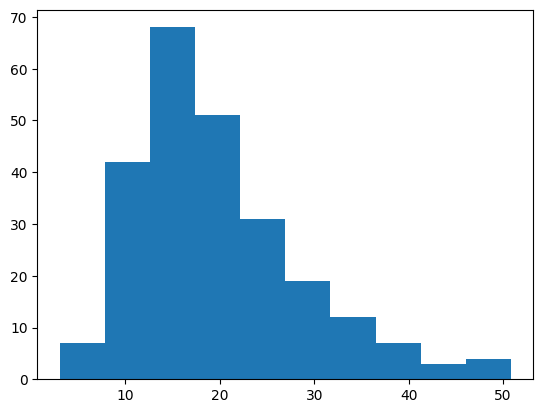

In [ ]:
plt.hist(df_tips.total_bill)

<Axes: xlabel='total_bill'>

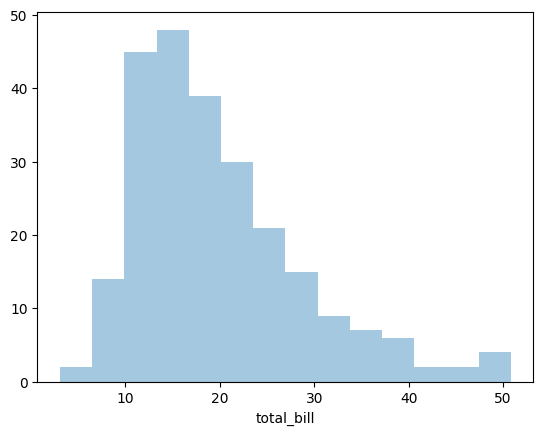

In [ ]:
import seaborn as sns
sns.distplot(df_tips.total_bill,kde=False)

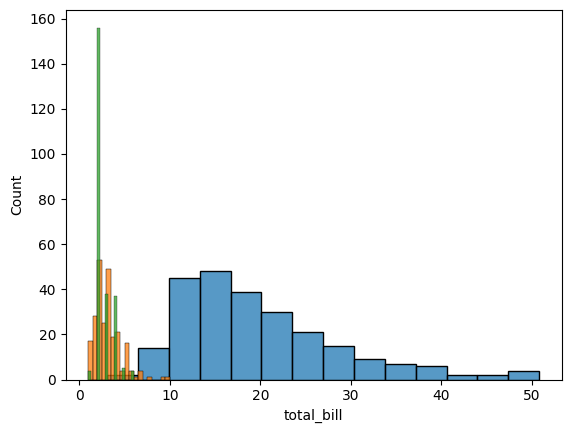

In [ ]:
for i in df_num.columns:
  sns.histplot(df_num[i])

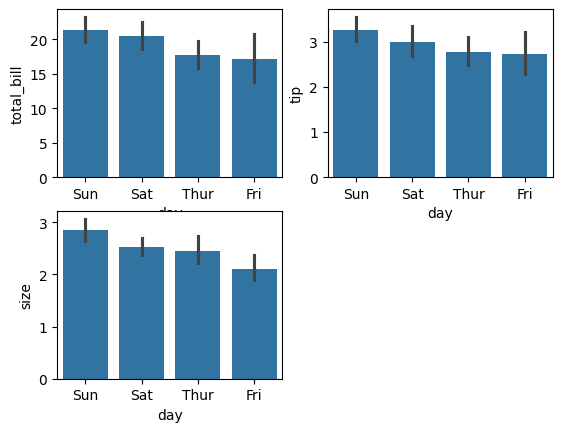

In [ ]:
t=1
for i in df_num:
    plt.subplot(2,2,t)
    sns.barplot(y=df_num[i],x=df_tips["day"])
    t=t+1

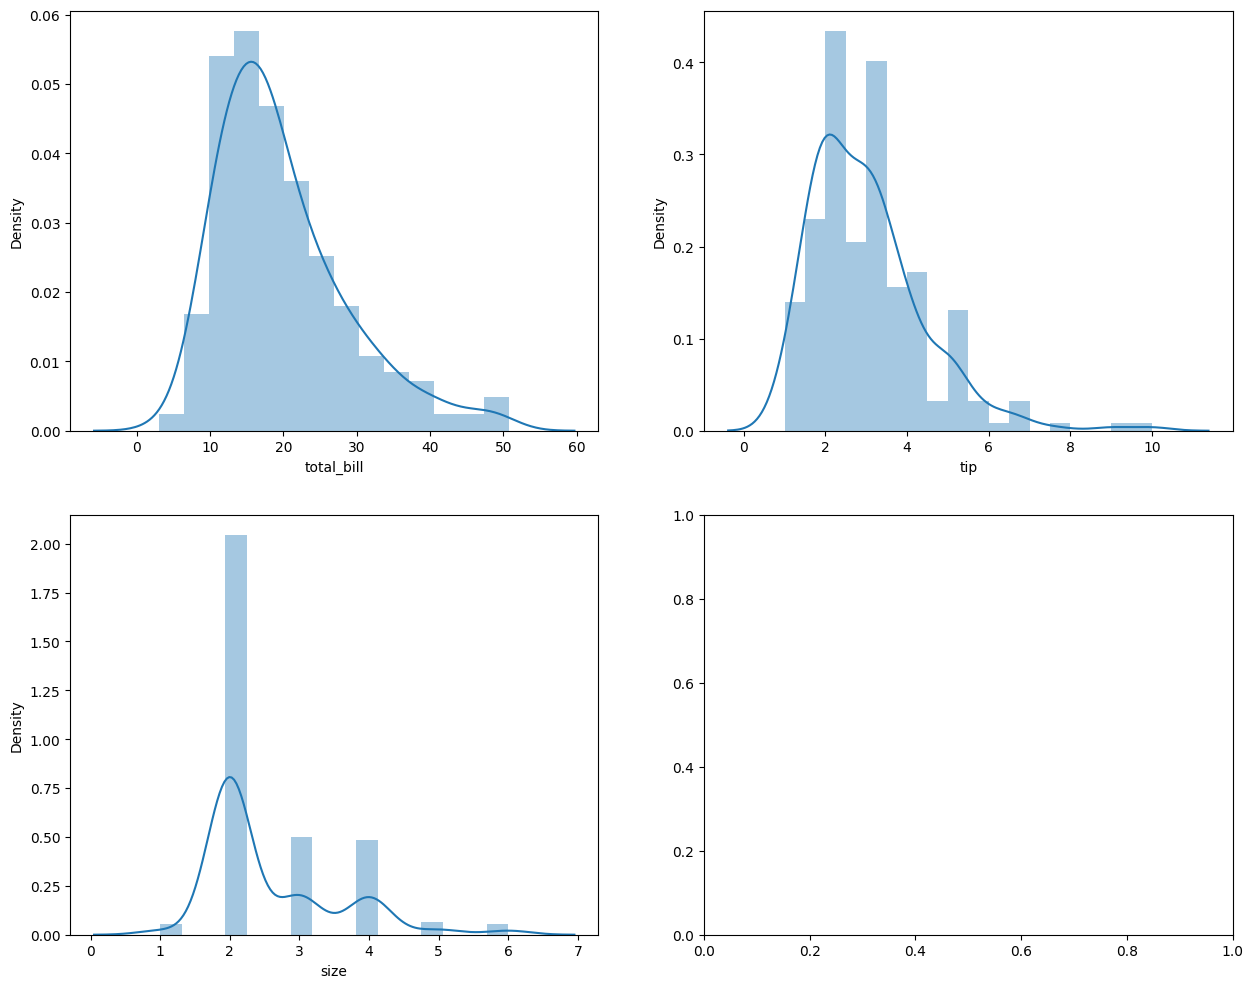

In [ ]:
fig,ax=plt.subplots(2,2,figsize=(15,12))

for i ,subplot in zip(df_num,ax.flatten()):
    sns.distplot(df_num[i],ax=subplot)

In [ ]:
data=np.array([[1,2,3],
               [4,5,6]])
data

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
data.flatten()

array([1, 2, 3, 4, 5, 6])

### 9.1 Line Plot
A line graph is the most uncomplicated plot that displays the relationship between the one independent and one dependent dataset. In this plot, the points are joined by straight line segments.

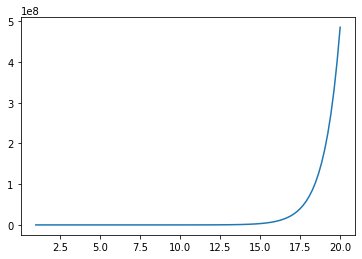

In [ ]:
# data
# create an array using linspace
X = np.linspace(1,20,100)
# create an array by taking exponential of X
Y = np.exp(X)

# line plot
plt.plot(X,Y)

# display the plot
plt.show()

From the plot, it can be observed that as X increases, Y  increases exponential.


**The above plot can be represented not only by a solid line, but also a dotted line with varied thickness. The points can be marked explicitly using any symbol.**

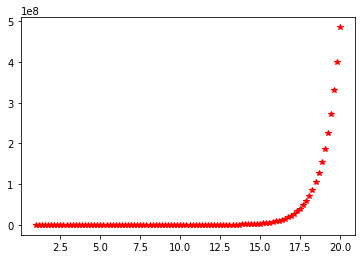

In [ ]:
# data
# create an array using linspace
X = np.linspace(1,20,100)
# create an array by taking exponential of X
Y = np.exp(X)

# line plot
# the argument 'r*' plots each point as a red '*'
plt.plot(X,Y, 'r*')

# display the plot
plt.show()

We can change the colours or shapes of the data points.

There can be multiple line plots in one plot. Let us plot three plots together in a single graph. Also, add a plot title.

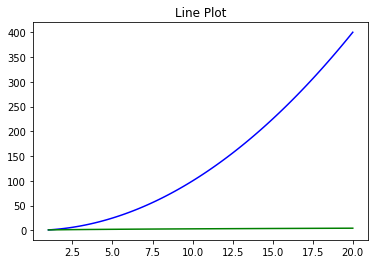

In [ ]:
# data
# create an array using linspace
X = np.linspace(1,20,100)
# create an array by taking square of X
Y_square = np.square(X)
# create an array by taking squareroot of X
Y_sqrt = np.sqrt(X)

# line plot
plt.plot( X,Y_square,'b', X,Y_sqrt,'g')

# add title to the plot
plt.title('Line Plot')

# display the plot
plt.show()

### 9.2 Scatter Plot

A scatter plot is a set of points plotted on horizontal and vertical axes. The scatter plot can be used to study the correlation between the two variables. One can also detect the extreme data points using a scatter plot.

In [ ]:
# check the head() of the tips dataset
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


Plot the scatter plot for the variables 'total_bill' and 'tip'

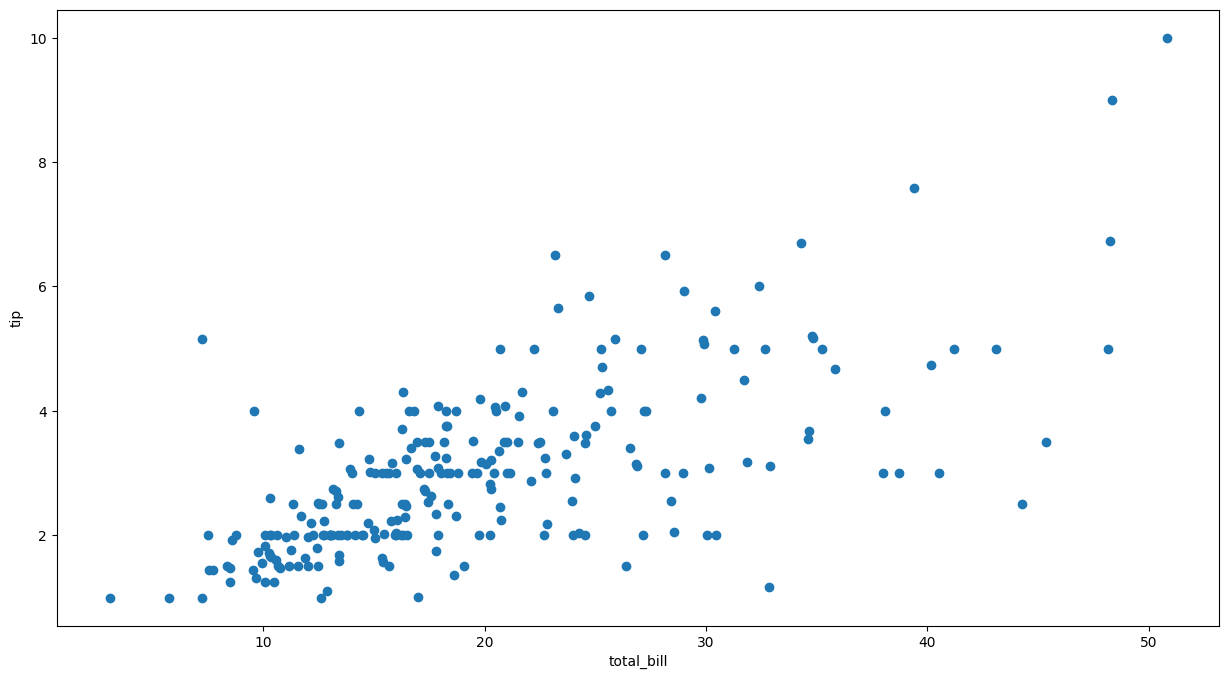

In [ ]:
# data
# let X be the column of total bill
X = df_tips['total_bill']
# let Y be the column of the tip collected
Y = df_tips['tip']

# set the plot size
plt.figure(figsize=(15,8))

# plot the scatter plot
plt.scatter(X,Y)

# add the axes labels to the plot
plt.xlabel('total_bill')
plt.ylabel('tip')

# display the plot
plt.show()

<Axes: xlabel='total_bill', ylabel='tip'>

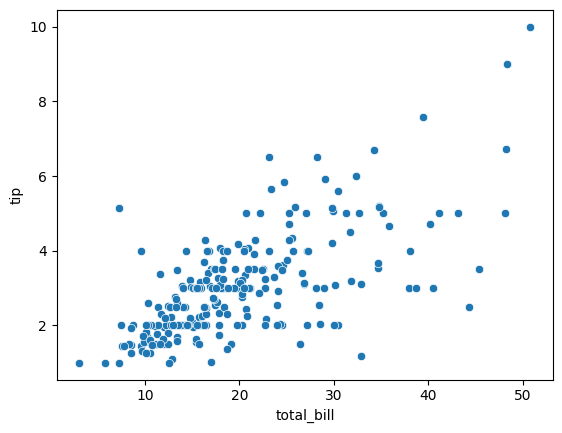

In [ ]:
sns.scatterplot(data=df_tips, x="total_bill", y="tip")

We can add different colours, opacity, and shape of data points. Let us customize the above plot.

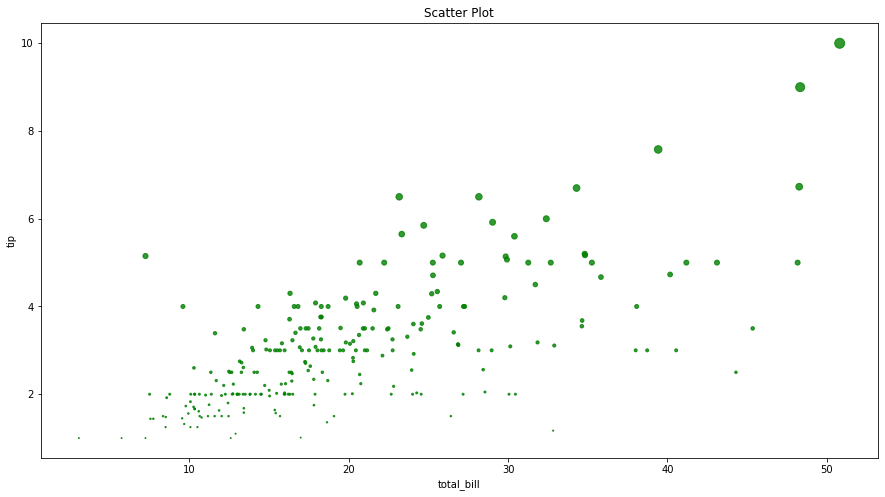

In [ ]:
# plot the scatter plot for the variables 'total_bill' and 'tip'

# data
# let X be the column of total bill
X = df_tips['total_bill']
# let Y be the column of the tip collected
Y = df_tips['tip']

# set the plot size
plt.figure(figsize=(15,8))

# plot the scatter plot
# s is for shape, c is for colour, alpha is for opacity (0 < alpha < 1)
plt.scatter(X, Y, s = np.array(Y)**2, c= 'green', alpha= 0.8)

# add title
plt.title('Scatter Plot')

# add the axes labels to the plot
plt.xlabel('total_bill')
plt.ylabel('tip')

# display the plot
plt.show()

The bubbles with higher radius display that the tip amount is more as compared to the bubbles with less radius.

### 9.3 Bar Plot
 To display categorical data use a  bar plot with bars having lengths proportional to the values that they represent. The comparison between different categories of a categorical variable can be made by studying a bar plot. <br><br>
                        In the vertical bar plot, the X-axis displays the categorical variable, and Y-axis contains the values corresponding to different categories.

In [ ]:
# the variable 'smoker' is categorical
# check categories in the variable
set(df_tips['smoker'])

{'No', 'Yes'}

<Axes: ylabel='Density'>

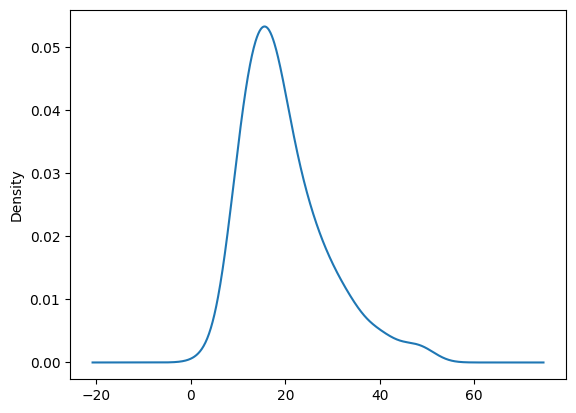

In [ ]:
df_tips.total_bill.plot(kind="kde")

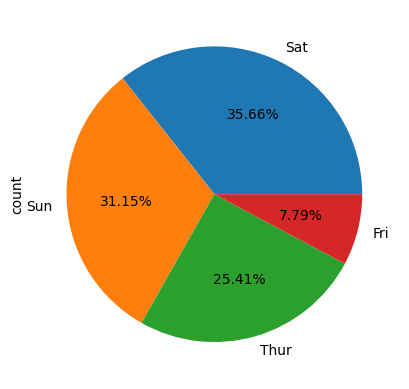

In [ ]:
# bar plot to get the count of smokers and non-smokers in the data

# kind='bar' plots a bar plot
# 'rot = 0' returns the categoric labels horizontally
df_tips.day.value_counts().plot(kind='pie', autopct="%.2f%%")

# display the plot
plt.show()

Let us add the count of smokers and non-smokers, axes labels and title to the above plot.

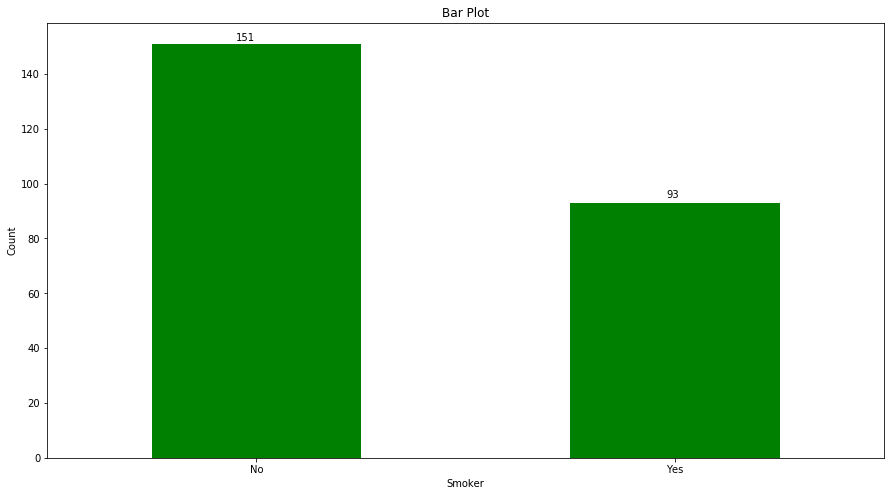

In [ ]:
# bar plot to get the count of smokers and non-smokers in the data

# set the plot size
plt.figure(figsize=(15,8))

# kind='bar' plots a bar plot
# 'rot = 0' returns the categoric labels horizontally
# 'color' can be used to add a specific colour
df_tips.smoker.value_counts().plot(kind='bar', rot = 0, color = 'green')

# plt.text() adds the text to the plot
# x and y are positions on the axes
# s is the text to be added
plt.text(x = -0.05, y = df_tips.smoker.value_counts()[1]+1, s = df_tips.smoker.value_counts()[1])
plt.text(x = 0.98, y = df_tips.smoker.value_counts()[0]+2, s = df_tips.smoker.value_counts()[0])

# add plot title
plt.title('Bar Plot')

# add x-axis label
plt.xlabel('Smoker')

# add y-axis label
plt.ylabel('Count')

# display the plot
plt.show()

From the bar plot, we interpret that the proportion of non-smokers is more in the data.

### 9.4 Pie Plot
Pie plot is a graphical representation of univariate data. It is a circular graph divided into slices displaying the numerical proportion. For the categorical variable, each slice of the pie plot corresponds to each of the categories.

In [ ]:
# check the head() of the tips dataset
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# categories in the 'day' variable
df_tips.day.value_counts()

Sat     87
Sun     76
Thur    62
Fri     19
Name: day, dtype: int64

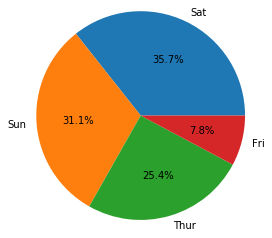

In [ ]:
# plot the occurrence of different days in the dataset

# 'autopct' displays the percentage upto 1 decimal place
# 'radius' sets the radius of the pie plot
# 'labels' are the labels given to each section
plt.pie(df_tips.day.value_counts(), autopct = '%.1f%%', radius = 1.2, labels = ['Sat', 'Sun','Thur','Fri'])

# display the plot
plt.show()

From the above pie plot, we see that the data has a high proportion for Saturday followed by Sunday.


**Exploded pie plot** is a plot in which one or more sectors are separated from the disc

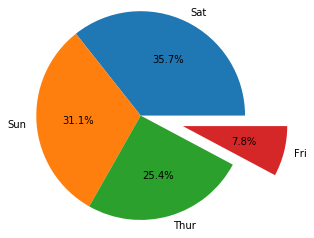

In [ ]:
# plot the occurrence of different days in the dataset

# 'autopct' displays the percentage upto 1 decimal place
# 'radius' sets the radius of the pie plot
# 'labels' are the labels given to each section
# 'explode' specifies the radius with which to offset each section
plt.pie(df_tips.day.value_counts(), autopct = '%.1f%%', radius = 1.2, labels = ['Sat', 'Sun','Thur','Fri'],
        explode = [0,0,0,0.5])

# display the plot
plt.show()

**Donut pie plot** is a type of pie plot in which there is a hollow center representing a doughnut.

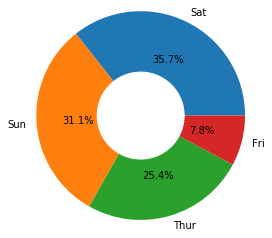

In [ ]:
# plot the occurrence of different days in the dataset

# pie plot
# 'autopct' displays the percentage upto 1 decimal place
# 'radius' sets the radius of the pie plot
# 'labels' are the labels given to each section
plt.pie(df_tips.day.value_counts(), autopct = '%.1f%%', radius = 1.2, labels = ['Sat', 'Sun','Thur','Fri'])

# add a circle at the center

circle =  plt.Circle( (0,0), radius = 0.5, color='white')
plot = plt.gcf()
plot.gca().add_artist(circle)

# display the plot
plt.show()

### 9.5 Histogram
A histogram is used to display the distribution and spread of the continuous variable. One axis represents the range of variable, and the other axis shows the frequency of the data points. In a histogram, there are no gaps between the bars.

In tips dataset, 'tip' is the continuous variable. Let us plot the histogram to understand the distribution of the variable.

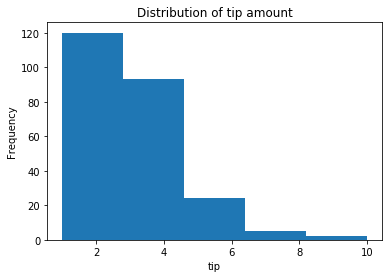

In [ ]:
# plot the histogram
# specify the number of bins, using 'bins' parameter
plt.hist(df_tips['tip'], bins= 5)

# add the graph title
plt.title('Distribution of tip amount')

# add th x-axis label
plt.xlabel('tip')

# # add th y-axis label
plt.ylabel('Frequency')

# display the plot
plt.show()

From the above plot, we can see that the tip amount is positively skewed.

### 9.6 Box Plot
Boxplot is a way to visualize the five-number summary of the variable. The five-number summary includes the numerical quantities like minimum, first quartile (Q1), median (Q2), third quartile (Q3), and maximum. It gives information about the outliers in the data. Detecting and removing outliers is one of the essential steps in exploratory data analysis. Boxplots also tells about the distribution of the data.

Plot the boxplot of 'total_bill' to check the distribution and presence of outliers in the variable.

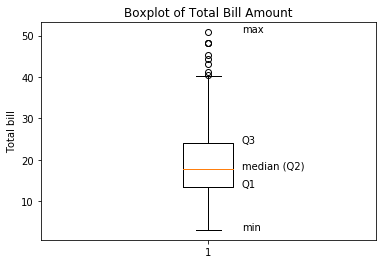

In [ ]:
# plot a boxplot of total bill
plt.boxplot(df_tips['total_bill'])

# add labels for five number summary using text()
# x is location on x-axis
# y is the location on y-axis
# s is the text
plt.text(x = 1.1, y = df_tips['total_bill'].min(), s ='min')              # for minimun
plt.text(x = 1.1, y = df_tips.total_bill.quantile(0.25), s ='Q1')         # for quartile 1
plt.text(x = 1.1, y = df_tips['total_bill'].median(), s ='median (Q2)')   # for quartile 2
plt.text(x = 1.1, y = df_tips.total_bill.quantile(0.75), s ='Q3')         # for quartile 3
plt.text(x = 1.1, y = df_tips['total_bill'].max(), s ='max')              # for maximum


# add the graph title
plt.title('Boxplot of Total Bill Amount')

# add the y-axis label
plt.ylabel('Total bill')

# display the plot
plt.show()

The above boxplot clearly shows the presence of outliers above the horizontal line. We can add an arrow to showcase the outliers. Also, the median (Q2) is represented by the orange line, which is nearer to Q1 than Q3, indicating that the total bill is positively skewed.

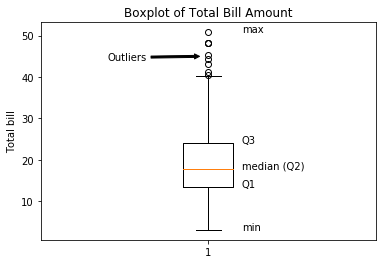

In [ ]:
# plot a distribution of total bill
plt.boxplot(df_tips['total_bill'])

# add labels for five number summary using text()
# x is location on x-axis
# y is the location on y-axis
# s is the text
plt.text(x = 1.1, y = df_tips['total_bill'].min(), s ='min')              # for minimun
plt.text(x = 1.1, y = df_tips.total_bill.quantile(0.25), s ='Q1')         # for quartile 1
plt.text(x = 1.1, y = df_tips['total_bill'].median(), s ='median (Q2)')   # for quartile 2
plt.text(x = 1.1, y = df_tips.total_bill.quantile(0.75), s ='Q3')         # for quartile 3
plt.text(x = 1.1, y = df_tips['total_bill'].max(), s ='max')              # for maximum

# add an arrow (annonate) to show the outliers
# xy is the location of the head of the arrow
# xytext is the location of the text
# arrowprops specify the properties of the arrow
# facecolor specifies the arrow color
# arrowstyle specifies the arrow stype
plt.annotate('Outliers', xy = (0.98,45),xytext=(0.7, 44), arrowprops = dict(facecolor='black', arrowstyle = 'simple'))

# add the graph title
plt.title('Boxplot of Total Bill Amount')
# add the y-axis label
plt.ylabel('Total bill')

# display the plot
plt.show()

### 9.7 Area Plot
Area plot is a graphical representation of quantitative data based on the line plot. The area under the line plot is shaded. <br>
                        Usually, it is used to compare the two or more quantities.

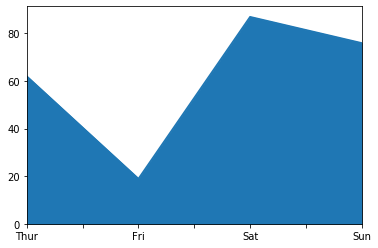

In [ ]:
# value_counts counts the number of observations for each day
# sorts the index - thursday to be first
# plot.area() plots area plot
df_tips['day'].value_counts().sort_index().plot.area()

# display the plot
plt.show()

The above plot gives the count of observations for each day. We see that the highest number of tips collected are on Saturday.